## Step 1: Setup and Data Loading
Objective: Set up your environment and load both content sources.

In [30]:
pip install langchain langchain-community pypdf2 python-dotenv openai tiktoken

Note: you may need to restart the kernel to use updated packages.


In [31]:
pip install -q langchain-text-splitters

Note: you may need to restart the kernel to use updated packages.


In [32]:
from langchain.text_splitter import CharacterTextSplitter

In [33]:
pip install "urllib3<2"

Note: you may need to restart the kernel to use updated packages.


In [34]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [35]:
from PyPDF2 import PdfReader
from pathlib import Path

# Check what files are in this folder
list(Path(".").iterdir())

[PosixPath('podcast_transcript.txt'),
 PosixPath('READ_ME.md'),
 PosixPath('part_001.m4a'),
 PosixPath('part_000.m4a'),
 PosixPath('requirements.txt'),
 PosixPath(' chunking_strategies.ipynb'),
 PosixPath('ai_hleg_ethics_guidelines_for_trustworthy_ai-en_87F84A41-A6E8-F38C-BFF661481B40077B_60419.pdf'),
 PosixPath('The_Blueprint_For_Trustworthy_AI.m4a'),
 PosixPath('.env'),
 PosixPath('chunking_strategies.ipynb'),
 PosixPath('ethics_guidelines_for_trustworthy_ai-fr_87FE7A3C-D03D-9305-81A653DDA84B5A60_60427.pdf')]

In [36]:
from PyPDF2 import PdfReader
from pathlib import Path

# Update these paths if your files are in a different folder
pdf_file = "ai_hleg_ethics_guidelines_for_trustworthy_ai-en_87F84A41-A6E8-F38C-BFF661481B40077B_60419.pdf"
audio_file = "The_Blueprint_For_Trustworthy_AI.m4a"

print(Path(pdf_file).exists())
print(Path(audio_file).exists())

True
True


In [37]:
 reader = PdfReader(pdf_file)

pdf_text = ""

for page in reader.pages:
    text = page.extract_text()
    if text:
        pdf_text += text + "\n"

print("PDF characters:", len(pdf_text))
print(pdf_text[:500])

PDF characters: 158079
 
  
 
 
 
INDEPENDENT  
HIGH-LEVEL EXPERT GROUP ON  
ARTIFICIAL INTELLIGENCE  
SET UP BY THE EUROPEAN COMMISSION  
 
 
 
 
 
 
ETHICS GUIDELINES  
FOR TRUSTWORTHY AI 
 
 
 
  
 
ETHICS GUIDELINES  FOR  TRUSTWORTHY  AI 
 
High -Level Expert Group on Artificial Intelligence  
 
 
 
 
 
 
 
 
This document was written by the High -Level Expert Group on AI (AI HLEG) . The members of the AI HLEG 
named in this document support the overall framework for Trustworthy  AI put forward in these Guidelines


In [38]:
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

client = OpenAI()

In [39]:
with open(audio_file, "rb") as audio:
    transcript = client.audio.transcriptions.create(
        model="whisper-1",
        file=audio
    )

podcast_text = transcript.text

with open("podcast_transcript.txt", "w", encoding="utf-8") as f:
    f.write(podcast_text)

print("Podcast characters:", len(podcast_text))
print(podcast_text[:500])

APIStatusError: Error code: 413 - {'error': {'message': '413: Maximum content size limit (26214400) exceeded (26424488 bytes read)', 'type': 'server_error', 'param': None, 'code': None}, 'usage': {'type': 'duration', 'seconds': 0}}

In [ ]:
from pathlib import Path
from openai import OpenAI

client = OpenAI()

audio_parts = sorted(Path(".").glob("part_*.m4a"))

full_transcript = []

for part in audio_parts:
    print(f"Transcribing {part.name}...")

    with open(part, "rb") as audio:
        transcript = client.audio.transcriptions.create(
            model="whisper-1",
            file=audio
        )

    full_transcript.append(transcript.text)

podcast_text = "\n\n".join(full_transcript)

with open("podcast_transcript.txt", "w", encoding="utf-8") as f:
    f.write(podcast_text)

print("Podcast characters:", len(podcast_text))
print(podcast_text[:500])

Transcribing part_000.m4a...
Transcribing part_001.m4a...
Podcast characters: 16408
So imagine for a second you're driving across, I don't know, a massive suspension bridge. Okay. You don't pull over halfway across, get out and demand to see the blueprints, right? You don't interview the welding crew. No. You just, you trust it. You just drive. You trust the bridge. You trust the engineering standards, the inspections, the laws that say this thing won't fail. Right. It's trust in the infrastructure. It's invisible, but it's there. Exactly. But now let's switch gears. Think abou


In [ ]:
print(len(pdf_text))
print(len(podcast_text))

158079
16408


## Step 2: Implement Fixed-Size Chunking
Objective: Create fixed-size chunks for both documents.

**What to do:**

Use:
* CharacterTextSplitter with fixed chunk size
* Experiment with different sizes: 500, 1000, 2000 characters
* Try different overlap values: 0, 50, 100 characters
* Compare results between podcast and PDF

In [ ]:
from langchain.text_splitter import CharacterTextSplitter

In [ ]:
def create_fixed_chunks(text, chunk_size, overlap):
    splitter = CharacterTextSplitter(
        separator="\n",
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        length_function=len
    )

    return splitter.split_text(text)


In [ ]:
chunk_sizes = [500, 1000, 2000]
overlaps = [0, 50, 100]

for size in chunk_sizes:
    for overlap in overlaps:

        pdf_chunks = create_fixed_chunks(pdf_text, size, overlap)
        podcast_chunks = create_fixed_chunks(podcast_text, size, overlap)

        print(f"\nChunk Size: {size} | Overlap: {overlap}")
        print(f"PDF Chunks: {len(pdf_chunks)}")
        print(f"Podcast Chunks: {len(podcast_chunks)}")

Created a chunk of size 10571, which is longer than the specified 500
Created a chunk of size 10571, which is longer than the specified 500
Created a chunk of size 10571, which is longer than the specified 500
Created a chunk of size 10571, which is longer than the specified 1000
Created a chunk of size 10571, which is longer than the specified 1000
Created a chunk of size 10571, which is longer than the specified 1000
Created a chunk of size 10571, which is longer than the specified 2000
Created a chunk of size 10571, which is longer than the specified 2000
Created a chunk of size 10571, which is longer than the specified 2000



Chunk Size: 500 | Overlap: 0
PDF Chunks: 350
Podcast Chunks: 2

Chunk Size: 500 | Overlap: 50
PDF Chunks: 354
Podcast Chunks: 2

Chunk Size: 500 | Overlap: 100
PDF Chunks: 367
Podcast Chunks: 2

Chunk Size: 1000 | Overlap: 0
PDF Chunks: 167
Podcast Chunks: 2

Chunk Size: 1000 | Overlap: 50
PDF Chunks: 168
Podcast Chunks: 2

Chunk Size: 1000 | Overlap: 100
PDF Chunks: 171
Podcast Chunks: 2

Chunk Size: 2000 | Overlap: 0
PDF Chunks: 82
Podcast Chunks: 2

Chunk Size: 2000 | Overlap: 50
PDF Chunks: 82
Podcast Chunks: 2

Chunk Size: 2000 | Overlap: 100
PDF Chunks: 83
Podcast Chunks: 2


In [ ]:
print(pdf_chunks[0])
print("-" * 50)
print(pdf_chunks[1])

INDEPENDENT  
HIGH-LEVEL EXPERT GROUP ON  
ARTIFICIAL INTELLIGENCE  
SET UP BY THE EUROPEAN COMMISSION  
 
 
 
 
 
 
ETHICS GUIDELINES  
FOR TRUSTWORTHY AI 
 
 
 
  
 
ETHICS GUIDELINES  FOR  TRUSTWORTHY  AI 
 
High -Level Expert Group on Artificial Intelligence  
 
 
 
 
 
 
 
 
This document was written by the High -Level Expert Group on AI (AI HLEG) . The members of the AI HLEG 
named in this document support the overall framework for Trustworthy  AI put forward in these Guidelines, 
although they do not necessarily agree with every single statement in the document .  
 
The Trustworthy  AI assessment  list presented in Chapter III of this document will undergo a piloting phase by 
stakeholders to gather practical feedback. A revised version  of the assessment  list, taking into account the 
feedback gathered through the piloting phase, will be presented to the Eu ropean Commission in early 2020.  
 
 
The AI HLEG is an independent expert group that was set up by the European Commis

In [ ]:
print(podcast_chunks[0])
print("-" * 50)
print(podcast_chunks[1])

So imagine for a second you're driving across, I don't know, a massive suspension bridge. Okay. You don't pull over halfway across, get out and demand to see the blueprints, right? You don't interview the welding crew. No. You just, you trust it. You just drive. You trust the bridge. You trust the engineering standards, the inspections, the laws that say this thing won't fail. Right. It's trust in the infrastructure. It's invisible, but it's there. Exactly. But now let's switch gears. Think about the algorithm that just denied your mortgage application or the AI system scanning your face at the airport. Do you have that same trust? And I mean, honestly, should you? That is the defining question of our decade, I think. We've moved past the wow phase of AI and straight into the wait a minute phase. Today we are digging into the blueprint for that trust. We're unpacking a document that is arguably the Magna Carta for ethical computing, the ethics guidelines for trustworthy AI. This is a h

In [ ]:
!pip install pandas

  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 26.6 MB/s  0:00:00 eta 0:00:01
Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]


In [ ]:
import pandas as pd

results = []

for size in [500, 1000, 2000]:
    for overlap in [0, 50, 100]:

        pdf_chunks = create_fixed_chunks(pdf_text, size, overlap)
        podcast_chunks = create_fixed_chunks(podcast_text, size, overlap)

        results.append({
            "Chunk Size": size,
            "Overlap": overlap,
            "PDF Chunks": len(pdf_chunks),
            "Podcast Chunks": len(podcast_chunks)
        })

df = pd.DataFrame(results)
df

Created a chunk of size 10571, which is longer than the specified 500
Created a chunk of size 10571, which is longer than the specified 500
Created a chunk of size 10571, which is longer than the specified 500
Created a chunk of size 10571, which is longer than the specified 1000
Created a chunk of size 10571, which is longer than the specified 1000
Created a chunk of size 10571, which is longer than the specified 1000
Created a chunk of size 10571, which is longer than the specified 2000
Created a chunk of size 10571, which is longer than the specified 2000
Created a chunk of size 10571, which is longer than the specified 2000


,Chunk Size,Overlap,PDF Chunks,Podcast Chunks
0,500,0,350,2
1,500,50,354,2
2,500,100,367,2
3,1000,0,167,2
4,1000,50,168,2
5,1000,100,171,2
6,2000,0,82,2
7,2000,50,82,2
8,2000,100,83,2


In [ ]:
full_transcript = []

for part in audio_parts:
    print(f"Transcribing {part.name}...")

    with open(part, "rb") as audio:
        transcript = client.audio.transcriptions.create(
            model="whisper-1",
            file=audio
        )

    full_transcript.append(transcript.text)

podcast_text = "\n\n".join(full_transcript)

with open("podcast_transcript.txt", "w", encoding="utf-8") as f:
    f.write(podcast_text)

print("Podcast characters:", len(podcast_text))
print(podcast_text[:500])

Transcribing part_000.m4a...
Transcribing part_001.m4a...
Podcast characters: 16408
So imagine for a second you're driving across, I don't know, a massive suspension bridge. Okay. You don't pull over halfway across, get out and demand to see the blueprints, right? You don't interview the welding crew. No. You just, you trust it. You just drive. You trust the bridge. You trust the engineering standards, the inspections, the laws that say this thing won't fail. Right. It's trust in the infrastructure. It's invisible, but it's there. Exactly. But now let's switch gears. Think abou


In [ ]:
with open("podcast_transcript.txt", "r", encoding="utf-8") as f:
    podcast_text = f.read()

print(len(podcast_text))

16408


In [ ]:
from PyPDF2 import PdfReader

reader = PdfReader("ai_hleg_ethics_guidelines_for_trustworthy_ai-en_87F84A41-A6E8-F38C-BFF661481B40077B_60419.pdf")

pdf_text = ""

for page in reader.pages:
    text = page.extract_text()
    if text:
        pdf_text += text

print(len(pdf_text))

158038


In [ ]:
from langchain.text_splitter import CharacterTextSplitter

splitter = CharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100
)

pdf_chunks = splitter.split_text(pdf_text)
podcast_chunks = splitter.split_text(podcast_text)

print("PDF chunks:", len(pdf_chunks))
print("Podcast chunks:", len(podcast_chunks))

Created a chunk of size 10571, which is longer than the specified 1000


PDF chunks: 1
Podcast chunks: 2


In [ ]:
print(pdf_chunks[0])
print("-" * 50)
print(podcast_chunks[0])

INDEPENDENT  
HIGH-LEVEL EXPERT GROUP ON  
ARTIFICIAL INTELLIGENCE  
SET UP BY THE EUROPEAN COMMISSION  
 
 
 
 
 
 
ETHICS GUIDELINES  
FOR TRUSTWORTHY AI 
 
  
  
 
ETHICS GUIDELINES  FOR  TRUSTWORTHY  AI 
 
High -Level Expert Group on Artificial Intelligence  
 
 
 
 
 
 
 
 
This document was written by the High -Level Expert Group on AI (AI HLEG) . The members of the AI HLEG 
named in this document support the overall framework for Trustworthy  AI put forward in these Guidelines, 
although they do not necessarily agree with every single statement in the document .  
 
The Trustworthy  AI assessment  list presented in Chapter III of this document will undergo a piloting phase by 
stakeholders to gather practical feedback. A revised version  of the assessment  list, taking into account the 
feedback gathered through the piloting phase, will be presented to the Eu ropean Commission in early 2020.  
 
 
The AI HLEG is an independent expert group that was set up by the European Commiss

Fixed-size chunking created chunks of about 1000 characters with 100 characters of overlap. 
The PDF produced more chunks because it is longer than the podcast transcript. 
This strategy is simple and predictable, but it may split ideas or sentences awkwardly.

In [ ]:
from langchain.text_splitter import CharacterTextSplitter

fixed_results = []

for size in [500, 1000, 2000]:
    for overlap in [0, 50, 100]:
        splitter = CharacterTextSplitter(
            separator="\n",
            chunk_size=size,
            chunk_overlap=overlap,
            length_function=len
        )

        pdf_chunks = splitter.split_text(pdf_text)
        podcast_chunks = splitter.split_text(podcast_text)

        fixed_results.append({
            "strategy": "Fixed-size",
            "chunk_size": size,
            "overlap": overlap,
            "pdf_chunks": len(pdf_chunks),
            "podcast_chunks": len(podcast_chunks),
            "avg_pdf_chunk_length": round(sum(len(c) for c in pdf_chunks) / len(pdf_chunks)),
            "avg_podcast_chunk_length": round(sum(len(c) for c in podcast_chunks) / len(podcast_chunks))
        })

fixed_results

Created a chunk of size 10571, which is longer than the specified 500
Created a chunk of size 10571, which is longer than the specified 500
Created a chunk of size 10571, which is longer than the specified 500
Created a chunk of size 10571, which is longer than the specified 1000
Created a chunk of size 10571, which is longer than the specified 1000
Created a chunk of size 10571, which is longer than the specified 1000
Created a chunk of size 10571, which is longer than the specified 2000
Created a chunk of size 10571, which is longer than the specified 2000
Created a chunk of size 10571, which is longer than the specified 2000


[{'strategy': 'Fixed-size',
  'chunk_size': 500,
  'overlap': 0,
  'pdf_chunks': 350,
  'podcast_chunks': 2,
  'avg_pdf_chunk_length': 446,
  'avg_podcast_chunk_length': 8203},
 {'strategy': 'Fixed-size',
  'chunk_size': 500,
  'overlap': 50,
  'pdf_chunks': 354,
  'podcast_chunks': 2,
  'avg_pdf_chunk_length': 448,
  'avg_podcast_chunk_length': 8203},
 {'strategy': 'Fixed-size',
  'chunk_size': 500,
  'overlap': 100,
  'pdf_chunks': 367,
  'podcast_chunks': 2,
  'avg_pdf_chunk_length': 446,
  'avg_podcast_chunk_length': 8203},
 {'strategy': 'Fixed-size',
  'chunk_size': 1000,
  'overlap': 0,
  'pdf_chunks': 167,
  'podcast_chunks': 2,
  'avg_pdf_chunk_length': 940,
  'avg_podcast_chunk_length': 8203},
 {'strategy': 'Fixed-size',
  'chunk_size': 1000,
  'overlap': 50,
  'pdf_chunks': 168,
  'podcast_chunks': 2,
  'avg_pdf_chunk_length': 942,
  'avg_podcast_chunk_length': 8203},
 {'strategy': 'Fixed-size',
  'chunk_size': 1000,
  'overlap': 100,
  'pdf_chunks': 171,
  'podcast_chunks': 

In [ ]:
import pandas as pd

fixed_df = pd.DataFrame(fixed_results)
fixed_df

,strategy,chunk_size,overlap,pdf_chunks,podcast_chunks,avg_pdf_chunk_length,avg_podcast_chunk_length
0,Fixed-size,500,0,350,2,446,8203
1,Fixed-size,500,50,354,2,448,8203
2,Fixed-size,500,100,367,2,446,8203
3,Fixed-size,1000,0,167,2,940,8203
4,Fixed-size,1000,50,168,2,942,8203
5,Fixed-size,1000,100,171,2,941,8203
6,Fixed-size,2000,0,82,2,1923,8203
7,Fixed-size,2000,50,82,2,1927,8203
8,Fixed-size,2000,100,83,2,1923,8203


In [ ]:
print("PDF sample chunk:")
print(pdf_chunks[0])

print("\n" + "-" * 80 + "\n")

print("Podcast sample chunk:")
print(podcast_chunks[0])

PDF sample chunk:
INDEPENDENT  
HIGH-LEVEL EXPERT GROUP ON  
ARTIFICIAL INTELLIGENCE  
SET UP BY THE EUROPEAN COMMISSION  
 
 
 
 
 
 
ETHICS GUIDELINES  
FOR TRUSTWORTHY AI 
 
  
  
 
ETHICS GUIDELINES  FOR  TRUSTWORTHY  AI 
 
High -Level Expert Group on Artificial Intelligence  
 
 
 
 
 
 
 
 
This document was written by the High -Level Expert Group on AI (AI HLEG) . The members of the AI HLEG 
named in this document support the overall framework for Trustworthy  AI put forward in these Guidelines, 
although they do not necessarily agree with every single statement in the document .  
 
The Trustworthy  AI assessment  list presented in Chapter III of this document will undergo a piloting phase by 
stakeholders to gather practical feedback. A revised version  of the assessment  list, taking into account the 
feedback gathered through the piloting phase, will be presented to the Eu ropean Commission in early 2020.  
 
 
The AI HLEG is an independent expert group that was set up by th

### Fixed-Size Chunking Analysis

Fixed-size chunking is simple and predictable because it creates chunks based mainly on character count. However, it does not fully understand meaning or document structure.

In some cases, fixed-size chunking can break sentences or ideas in the middle, especially when the chunk boundary falls inside a long paragraph. It handles paragraph boundaries only partially because the splitter uses line breaks, but it is still controlled mostly by chunk size.

The podcast transcript handles fixed-size chunking slightly better because the language is conversational and flows in shorter spoken segments. The PDF is more structured, with sections, headers, and formal paragraphs, so fixed-size chunking can separate headings from the content they introduce.

## Step 3: Implement Recursive Character Chunking
Objective: Use recursive character splitting, which tries to preserve semantic boundaries.

**What to do:**

Use: 
* RecursiveCharacterTextSplitter (recommended by LangChain)
* Experiment with chunk sizes: 500, 1000, 2000 tokens
* Try different separators priority
* Compare with fixed-size results

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [ ]:
# Recursive character chunking (tries to split on paragraphs, then sentences, then words)
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]
)
 
pdf_chunks_recursive = recursive_splitter.split_text(pdf_text)
podcast_chunks_recursive = recursive_splitter.split_text(podcast_text)

In [ ]:
print("PDF recursive chunks:", len(pdf_chunks_recursive))
print("Podcast recursive chunks:", len(podcast_chunks_recursive))

PDF recursive chunks: 195
Podcast recursive chunks: 22


In [ ]:
print("First PDF recursive chunk:")
print(pdf_chunks_recursive[0])

print("\n" + "-" * 80 + "\n")

print("First Podcast recursive chunk:")
print(podcast_chunks_recursive[0])

First PDF recursive chunk:
INDEPENDENT  
HIGH-LEVEL EXPERT GROUP ON  
ARTIFICIAL INTELLIGENCE  
SET UP BY THE EUROPEAN COMMISSION  
 
 
 
 
 
 
ETHICS GUIDELINES  
FOR TRUSTWORTHY AI 
 
  
  
 
ETHICS GUIDELINES  FOR  TRUSTWORTHY  AI 
 
High -Level Expert Group on Artificial Intelligence  
 
 
 
 
 
 
 
 
This document was written by the High -Level Expert Group on AI (AI HLEG) . The members of the AI HLEG 
named in this document support the overall framework for Trustworthy  AI put forward in these Guidelines, 
although they do not necessarily agree with every single statement in the document .  
 
The Trustworthy  AI assessment  list presented in Chapter III of this document will undergo a piloting phase by 
stakeholders to gather practical feedback. A revised version  of the assessment  list, taking into account the 
feedback gathered through the piloting phase, will be presented to the Eu ropean Commission in early 2020.

------------------------------------------------------------

### Recursive Character Chunking Analysis

Recursive character chunking worked better than fixed-size chunking because it tries to split text using natural boundaries first, such as paragraph breaks, line breaks, sentences, and then words.

For the podcast transcript, recursive chunking helps preserve conversational flow better than fixed-size chunking.

For the PDF, recursive chunking is also stronger because it is more likely to keep headings and related paragraphs together.

Overall, recursive chunking preserves context better than fixed-size chunking.

## Step 4: Implement Token-Based Chunking
Objective: Chunk based on token count (more accurate for LLM context windows).


**What to do:**

Use: 
* TokenTextSplitter or calculate tokens manually
* Chunk to specific token counts (e.g., 500, 1000 tokens)
* Compare token-based vs character-based chunking

In [ ]:
from langchain.text_splitter import TokenTextSplitter

fixed_results = []

In [ ]:
# Token-based chunking
token_splitter = TokenTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)
 
pdf_chunks_tokens = token_splitter.split_text(pdf_text)
podcast_chunks_tokens = token_splitter.split_text(podcast_text)
 
print(f"PDF: {len(pdf_chunks_tokens)} chunks")
print(f"Podcast: {len(podcast_chunks_tokens)} chunks")
 
# Compare actual token counts - IMPORTANT!
import tiktoken
encoding = tiktoken.get_encoding("cl100k_base")
 
for i, chunk in enumerate(pdf_chunks_tokens[:3]):
    token_count = len(encoding.encode(chunk))
    print(f"Chunk {i+1}: {token_count} tokens, {len(chunk)} characters")

PDF: 85 chunks
Podcast: 8 chunks
Chunk 1: 404 tokens, 1789 characters
Chunk 2: 411 tokens, 1655 characters
Chunk 3: 463 tokens, 2115 characters


In [ ]:
for i, chunk in enumerate(podcast_chunks_tokens[:3]):
    token_count = len(encoding.encode(chunk))
    print(f"Podcast Chunk {i+1}: {token_count} tokens, {len(chunk)} characters")

Podcast Chunk 1: 501 tokens, 2314 characters
Podcast Chunk 2: 499 tokens, 2295 characters
Podcast Chunk 3: 497 tokens, 2459 characters


### Token-Based Chunking Results

Token-based chunking produced 85 chunks for the PDF and 8 chunks for the podcast transcript using a chunk size of 500 tokens and an overlap of 50 tokens.

The first three PDF chunks contained 404, 411, and 463 tokens. This shows that token-based chunking controls the size of chunks based on model-readable units instead of character count.

This approach is useful for RAG because language models process text as tokens, not characters. However, token-based chunking can still split sentences or paragraphs if the token limit is reached in the middle of an idea.

## Step 6: Visualize and Compare Results
Objective: Create visualizations to compare chunking strategies.

**What to do:**

* Create a comparison table of chunk statistics
* Visualize chunk size distributions
* Identify where chunks break (sentence boundaries, paragraphs, etc.)
* Document trade-offs

In [ ]:
!pip install --upgrade matplotlib

In [ ]:
import matplotlib
print(matplotlib.__version__)

3.9.4


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
with open("podcast_transcript.txt", "r", encoding="utf-8") as f:
    podcast_text = f.read()

print("Podcast loaded:", len(podcast_text))
print(podcast_text[:200])

Podcast loaded: 16408
So imagine for a second you're driving across, I don't know, a massive suspension bridge. Okay. You don't pull over halfway across, get out and demand to see the blueprints, right? You don't interview


In [ ]:
from langchain.text_splitter import CharacterTextSplitter, RecursiveCharacterTextSplitter, TokenTextSplitter

# Fixed-size chunks
fixed_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=1000,
    chunk_overlap=100,
    length_function=len
)

pdf_chunks = fixed_splitter.split_text(pdf_text)
podcast_chunks = fixed_splitter.split_text(podcast_text)

# Recursive chunks
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]
)

pdf_chunks_recursive = recursive_splitter.split_text(pdf_text)
podcast_chunks_recursive = recursive_splitter.split_text(podcast_text)

# Token-based chunks
token_splitter = TokenTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

pdf_chunks_tokens = token_splitter.split_text(pdf_text)
podcast_chunks_tokens = token_splitter.split_text(podcast_text)

print("Fixed PDF:", len(pdf_chunks))
print("Fixed Podcast:", len(podcast_chunks))
print("Recursive PDF:", len(pdf_chunks_recursive))
print("Recursive Podcast:", len(podcast_chunks_recursive))
print("Token PDF:", len(pdf_chunks_tokens))
print("Token Podcast:", len(podcast_chunks_tokens))

Created a chunk of size 10571, which is longer than the specified 1000


Fixed PDF: 171
Fixed Podcast: 2
Recursive PDF: 196
Recursive Podcast: 22
Token PDF: 85
Token Podcast: 8


## Comparison Table

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

def chunk_stats(strategy_name, source_name, chunks):
    lengths = [len(chunk) for chunk in chunks]
    token_lengths = [len(encoding.encode(chunk)) for chunk in chunks]

    return {
        "strategy": strategy_name,
        "source": source_name,
        "number_of_chunks": len(chunks),
        "avg_characters": round(sum(lengths) / len(lengths)),
        "min_characters": min(lengths),
        "max_characters": max(lengths),
        "avg_tokens": round(sum(token_lengths) / len(token_lengths)),
        "min_tokens": min(token_lengths),
        "max_tokens": max(token_lengths),
    }

summary_results = [
    chunk_stats("Fixed-size", "PDF", pdf_chunks),
    chunk_stats("Fixed-size", "Podcast", podcast_chunks),
    chunk_stats("Recursive", "PDF", pdf_chunks_recursive),
    chunk_stats("Recursive", "Podcast", podcast_chunks_recursive),
    chunk_stats("Token-based", "PDF", pdf_chunks_tokens),
    chunk_stats("Token-based", "Podcast", podcast_chunks_tokens),
]

summary_df = pd.DataFrame(summary_results)
summary_df

,strategy,source,number_of_chunks,avg_characters,min_characters,max_characters,avg_tokens,min_tokens,max_tokens
0,Fixed-size,PDF,171,942,396,999,196,110,278
1,Fixed-size,Podcast,2,8203,5835,10571,1728,1204,2251
2,Recursive,PDF,196,935,237,998,194,57,268
3,Recursive,Podcast,22,898,277,999,188,56,224
4,Token-based,PDF,85,2059,837,2374,428,240,472
5,Token-based,Podcast,8,2260,1398,2504,475,313,502


## Visualize Chunk Distribution

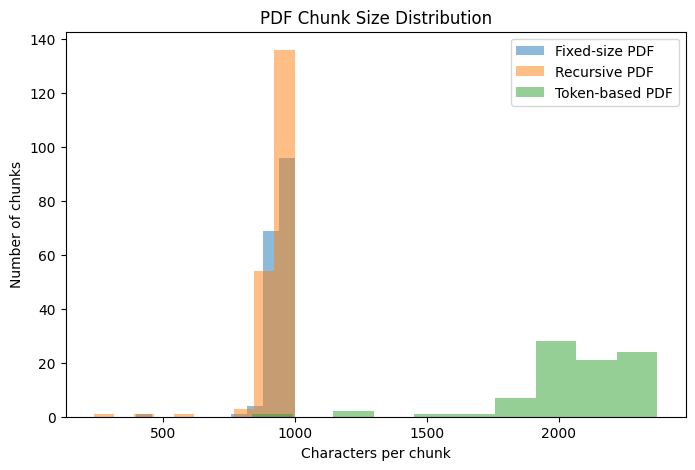

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist([len(chunk) for chunk in pdf_chunks], alpha=0.5, label="Fixed-size PDF")
plt.hist([len(chunk) for chunk in pdf_chunks_recursive], alpha=0.5, label="Recursive PDF")
plt.hist([len(chunk) for chunk in pdf_chunks_tokens], alpha=0.5, label="Token-based PDF")
plt.title("PDF Chunk Size Distribution")
plt.xlabel("Characters per chunk")
plt.ylabel("Number of chunks")
plt.legend()
plt.show()

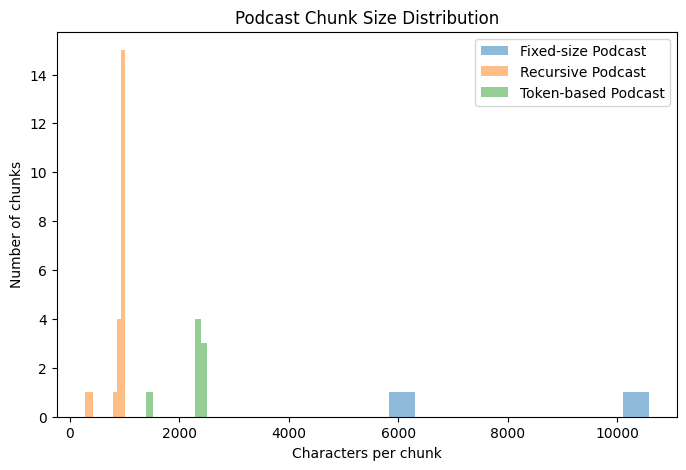

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist([len(chunk) for chunk in podcast_chunks], alpha=0.5, label="Fixed-size Podcast")
plt.hist([len(chunk) for chunk in podcast_chunks_recursive], alpha=0.5, label="Recursive Podcast")
plt.hist([len(chunk) for chunk in podcast_chunks_tokens], alpha=0.5, label="Token-based Podcast")
plt.title("Podcast Chunk Size Distribution")
plt.xlabel("Characters per chunk")
plt.ylabel("Number of chunks")
plt.legend()
plt.show()

In [ ]:
def identify_chunk_breaks(strategy_name, source_name, chunks):
    results = []

    for i, chunk in enumerate(chunks[:-1]):
        ending = chunk.strip()[-100:]

        if chunk.strip().endswith((".", "!", "?")):
            break_type = "Clean sentence boundary"
        elif chunk.strip().endswith((",", ";", ":")):
            break_type = "Possible mid-sentence break"
        else:
            break_type = "Likely middle of sentence/paragraph"

        results.append({
            "Strategy": strategy_name,
            "Source": source_name,
            "Chunk Number": i + 1,
            "Break Type": break_type,
            "Ending Preview": ending
        })

    return results


break_results = []

break_results += identify_chunk_breaks("Fixed-size", "PDF", pdf_chunks)
break_results += identify_chunk_breaks("Fixed-size", "Podcast", podcast_chunks)
break_results += identify_chunk_breaks("Recursive", "PDF", pdf_chunks_recursive)
break_results += identify_chunk_breaks("Recursive", "Podcast", podcast_chunks_recursive)
break_results += identify_chunk_breaks("Token-based", "PDF", pdf_chunks_tokens)
break_results += identify_chunk_breaks("Token-based", "Podcast", podcast_chunks_tokens)

break_df = pd.DataFrame(break_results)

break_summary = (
    break_df
    .groupby(["Strategy", "Source", "Break Type"])
    .size()
    .reset_index(name="Count")
)

break_summary

,Strategy,Source,Break Type,Count
0,Fixed-size,PDF,Clean sentence boundary,39
1,Fixed-size,PDF,Likely middle of sentence/paragraph,113
2,Fixed-size,PDF,Possible mid-sentence break,18
3,Fixed-size,Podcast,Clean sentence boundary,1
4,Recursive,PDF,Clean sentence boundary,42
5,Recursive,PDF,Likely middle of sentence/paragraph,140
6,Recursive,PDF,Possible mid-sentence break,13
7,Recursive,Podcast,Clean sentence boundary,1
8,Recursive,Podcast,Likely middle of sentence/paragraph,20
9,Token-based,PDF,Clean sentence boundary,3


In [ ]:
break_df.head(20)

,Strategy,Source,Chunk Number,Break Type,Ending Preview
0,Fixed-size,PDF,1,Clean sentence boundary,"ck gathered through the piloting phase, will b..."
1,Fixed-size,PDF,2,Likely middle of sentence/paragraph,on Artificial Intelligence (AI HLEG). Although...
2,Fixed-size,PDF,3,Likely middle of sentence/paragraph,II: Realising Trustworthy AI 14 \n1. Re...
3,Fixed-size,PDF,4,Likely middle of sentence/paragraph,nent in itself is necessary but not sufficient...
4,Fixed-size,PDF,5,Likely middle of sentence/paragraph,"n an approach founded on fundamental rights , ..."
5,Fixed-size,PDF,6,Possible mid-sentence break,"in risks and may have a negative impact , incl..."
6,Fixed-size,PDF,7,Clean sentence boundary, Consider technical and non -technical method...
7,Fixed-size,PDF,8,Likely middle of sentence/paragraph,rement s; disseminate results and open questio...
8,Fixed-size,PDF,9,Likely middle of sentence/paragraph,provid es a concrete and non-exhaustive Trust...
9,Fixed-size,PDF,10,Clean sentence boundary,"should be pursued, and critical concerns raise..."


### Step 6: Trade-Offs Between Chunking Strategies

Fixed-size chunking is the simplest and most predictable strategy. It creates chunks based on character length, which makes it easy to compare results across different chunk sizes and overlaps. However, it does not understand sentence meaning or document structure, so it can break sentences, paragraphs, or section context awkwardly.

Recursive character chunking preserves structure better because it tries to split text using paragraph breaks, line breaks, sentence endings, spaces, and finally individual characters. This makes it especially useful for structured PDF documents because it is more likely to keep headings and related paragraphs together.

Token-based chunking is useful for RAG and LLM workflows because models process text as tokens rather than characters. This gives better control over how much text is sent to the model. However, token-based chunking may still break sentences or paragraphs if the token limit is reached in the middle of an idea.

Overall, recursive character chunking is better for preserving natural text boundaries, while token-based chunking is better for controlling LLM input size. Fixed-size chunking is useful as a simple baseline but is the weakest strategy for preserving context.

## Step 7 Analyze Chunk Quality 
Objective:  Evaluate chunk quality by checking boundary preservation. 

**What to do:**
 * Check how often chunks break in the middle of sentences 
 * Check how often chunks break in the middle of paragraphs 
 * Identify which strategy preserves context best

In [ ]:
def analyze_chunk_quality(strategy_name, source_name, chunks):
    middle_sentence_breaks = 0
    clean_sentence_breaks = 0
    paragraph_breaks = 0

    for chunk in chunks[:-1]:
        clean = chunk.strip()

        if clean.endswith((".", "!", "?")):
            clean_sentence_breaks += 1
        else:
            middle_sentence_breaks += 1

        if "\n\n" in chunk[-10:]:
            paragraph_breaks += 1

    total = len(chunks) - 1

    return {
        "Strategy": strategy_name,
        "Source": source_name,
        "Total Boundaries": total,
        "Clean Sentence Breaks": clean_sentence_breaks,
        "Middle Sentence Breaks": middle_sentence_breaks,
        "Middle Sentence Break %": round((middle_sentence_breaks / total) * 100, 2),
        "Paragraph Boundary Breaks": paragraph_breaks,
        "Paragraph Boundary Break %": round((paragraph_breaks / total) * 100, 2)
    }

In [ ]:
quality_results = [
    analyze_chunk_quality("Fixed-size", "PDF", pdf_chunks),
    analyze_chunk_quality("Fixed-size", "Podcast", podcast_chunks),
    analyze_chunk_quality("Recursive", "PDF", pdf_chunks_recursive),
    analyze_chunk_quality("Recursive", "Podcast", podcast_chunks_recursive),
    analyze_chunk_quality("Token-based", "PDF", pdf_chunks_tokens),
    analyze_chunk_quality("Token-based", "Podcast", podcast_chunks_tokens),
]

quality_df = pd.DataFrame(quality_results)
quality_df

,Strategy,Source,Total Boundaries,Clean Sentence Breaks,Middle Sentence Breaks,Middle Sentence Break %,Paragraph Boundary Breaks,Paragraph Boundary Break %
0,Fixed-size,PDF,170,39,131,77.06,0,0.0
1,Fixed-size,Podcast,1,1,0,0.00,0,0.0
2,Recursive,PDF,195,42,153,78.46,0,0.0
3,Recursive,Podcast,21,1,20,95.24,0,0.0
4,Token-based,PDF,84,3,81,96.43,0,0.0
5,Token-based,Podcast,7,2,5,71.43,0,0.0


### Step 7: Chunk Quality Analysis

The chunk quality analysis checks how often chunks end at clean sentence boundaries compared with how often they break in the middle of sentences or paragraphs.

Fixed-size chunking is the weakest for boundary preservation because it follows character limits rather than meaning or structure.

Recursive character chunking preserves context best because it tries to split first on paragraph breaks, then line breaks, then sentence endings, spaces, and finally characters.

Token-based chunking is useful for LLM workflows because it controls input size according to tokens, but it may still split sentences or paragraphs when the token limit is reached.

Overall, recursive character chunking preserves natural context best, especially for the PDF. Token-based chunking is useful when the priority is preparing chunks for embedding or retrieval in an LLM system.

## Step 8: Make Recommendations
Objective: Document your findings and make recommendations.

**What to do:**

* Create a summary table comparing strategies
* Write recommendations for each content type
* Explain trade-offs and when to use each approach

## Chunking Strategy Recommendations

### Summary Table

| Strategy | PDF Performance | Podcast Performance | Main Strength | Main Weakness |
|----------|-----------------|--------------------|---------------|---------------|
| Fixed-Size | Works as a simple baseline, but may split sections or paragraphs awkwardly | Works reasonably well because podcast language is conversational | Simple and predictable | Weak context preservation |
| Recursive Character | Best for preserving PDF structure, headings, paragraphs, and sentence flow | Also works well for podcast flow | Preserves natural text boundaries | Slightly more complex |
| Token-Based | Useful for preparing PDF chunks for LLM retrieval | Strong for podcast transcript because it creates model-friendly chunks | Best aligned with LLM context windows | Can still break sentences or ideas |

---

### For PDF Documents:

**Recommended Strategy:** Recursive Character Chunking

**Reasoning:**
- PDFs usually have structure, including headings, sections, lists, and formal paragraphs.
- Recursive character chunking works best because it tries to split on paragraph breaks, then line breaks, then sentence endings, then words.
- This helps preserve the relationship between section headers and the content that follows.
- It also reduces the chance of cutting off important context in the middle of a structured explanation.

**Optimal chunk size and overlap:**
- Chunk size: 1000 characters
- Overlap: 100 to 200 characters

---

### For Podcast Transcripts:

**Recommended Strategy:** Token-Based Chunking

**Reasoning:**
- Podcast transcripts are conversational and less formally structured than PDFs.
- Token-based chunking works well because it creates chunks based on how language models process text.
- This is useful for RAG systems because the chunks are more consistent for embeddings and retrieval.
- The podcast transcript produced fewer chunks than the PDF, which makes sense because it is shorter and more conversational.

**Optimal chunk size and overlap:**
- Chunk size: 500 tokens
- Overlap: 50 tokens

---

### Trade-offs Summary:

| Strategy | Pros | Cons | Best For |
|----------|------|------|----------|
| Fixed-Size | Simple, predictable, easy to compare | Can break sentences, paragraphs, and context | Quick baseline experiments and uniform content |
| Recursive | Preserves structure, paragraphs, and sentence boundaries better | More complex than fixed-size chunking | Structured documents like PDFs |
| Token-Based | Accurate for LLM context windows and RAG pipelines | Requires a tokenizer and may still split ideas | LLM integration, embeddings, and retrieval |
| Semantic | Meaning-based and context-aware | Computationally expensive and slower | Complex content where meaning shifts matter |

In [ ]:
import pandas as pd